In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install --upgrade gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 21.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requi

In [ ]:
# run it two times one for model.py and evolution.py
from google.colab import files
uploaded = files.upload()

Saving evaluation.py to evaluation.py
Saving model.py to model.py


In [ ]:
from gensim.models      import Word2Vec
from model              import ConvAttnPool
import torch.nn.functional as F
import numpy as np
import pandas as pd
import torch
import os
import textwrap
from collections import defaultdict
import seaborn as sns


import matplotlib.pyplot as plt

In [ ]:
base_dir = "/content/drive/MyDrive/MIMIC/"
rawdata_base_path = "/content/drive/MyDrive/MIMIC/RawData/"

TEXT_PATH = rawdata_base_path + "train_full.csv"          # Discharge summaries and ICD-9 labels
DESC_PATH = rawdata_base_path + "ICD9_descriptions"         # Your uploaded file (tab-separated)
CODE_50_PATH = rawdata_base_path + "TOP_50_CODES.csv"
TRAIN_50_PATH = rawdata_base_path + "train_50.csv"
TEST_50_PATH = rawdata_base_path +  "test_50.csv"

# doc id
#instance = 1920
#instance = 2413
instance = 1000
model_mame = "model.tar"

In [ ]:
word_model = Word2Vec.load(base_dir + 'processed_full.w2v')
vocab_size, embed_size = word_model.wv.vectors.shape
print(f'{vocab_size=}', f'{embed_size=}')
embedding_table = torch.from_numpy(word_model.wv.vectors).type(torch.float32)
embedding_table = torch.concat([embedding_table,torch.zeros(size = (1,embed_size))], dim = 0)
print(f'{vocab_size=}', f'{embed_size=}') # Keep the since vocab_size refers to the last index, our padding index)

vocab_size=150853 embed_size=100
vocab_size=150853 embed_size=100


In [ ]:
X_train = np.load(base_dir + 'X_train.npy')
X_test  = np.load(base_dir + 'X_test.npy')

Y_train = np.load(base_dir + 'Y_train.npy')
Y_test  = np.load(base_dir + 'Y_test.npy')

X_train = torch.from_numpy(X_train).long()
Y_train = torch.from_numpy(Y_train).type(torch.float32)


X_test  = torch.from_numpy(X_test) .long()
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

### Utility Functions

In [ ]:
# Function to retrieve code description and ICD_ID using label index
def get_ICD_code_by_label_index(index):

  # Load ICD full description
  desc_df = pd.read_csv(DESC_PATH, sep='\t')  # Your uploaded file uses tab delimiter
  desc_df.columns = ['CODE', 'LONG_TITLE']
  desc_map = dict(zip(desc_df['CODE'].astype(str), desc_df['LONG_TITLE']))
  label_codes = list(desc_map.keys())

  # Load top 50 ICD_codes
  top_50_codes = pd.read_csv(CODE_50_PATH, header=None)
  top_50_map = dict(enumerate(top_50_codes[0]))

  # Get the ICD code from top_50
  ICD_code = top_50_map[index]

  # Get the description from full list
  desc = desc_map[ICD_code]

  return ICD_code, desc

#ICD_code, desc = get_ICD_code_by_label_index(2)
#print(ICD_code, desc)

In [ ]:
# Function to retrieve ICD description by ICD code
def get_ICD_desc_by_code(code):
  desc_df = pd.read_csv(DESC_PATH, sep='\t')  # Your uploaded file uses tab delimiter
  desc_df.columns = ['CODE', 'LONG_TITLE']
  desc_map = dict(zip(desc_df['CODE'].astype(str), desc_df['LONG_TITLE']))
  label_codes = list(desc_map.keys())
  desc = desc_map[code]
  return desc

#print(get_ICD_desc_by_code(ICD_code))

In [ ]:
# Function to retrieve label index by ICD code
def get_index_by_ICD_code(code):
  # Load the file with no header
  top_50_codes = pd.read_csv(CODE_50_PATH, header=None)

  # Create the dictionay of ICDcode --> index
  top_50_code_index = dict()
  index = 0
  for item in top_50_codes[0]:
    top_50_code_index[item] = index
    index+=1

  index = top_50_code_index[code]
  return index

In [ ]:
# Funtion to retrieve the document by document index from training dataset csv
def get_training_document_by_id(index):
  df = pd.read_csv(TRAIN_50_PATH)
  #print(df.head(1))
  document = df['TEXT'][index]
  labels = df['LABELS'][index]
  labels_list = labels.split(';')
  wrapped_document = textwrap.fill(document, width=50)

  return wrapped_document, labels_list

#document, labels_list = get_training_document_by_id(2413)
#print(document)
#print(labels_list)

#for code in labels_list:
#  print(code, " : ",  get_ICD_desc_by_code(code))


In [ ]:
# Function to convert token ID to word, handling padding or out-of-range
def decode_document(X_data, doc_index, word_model, skip_pad=True):
    """
    Decodes a tokenized document from X_data using a Word2Vec model.

    Args:
        X_data (torch.Tensor): Tensor of shape (num_docs, seq_len), each value is a token ID.
        doc_index (int): Index of the document to decode.
        word_model (gensim.models.Word2Vec): Loaded Word2Vec model.
        skip_pad (bool): If True, skips tokens beyond vocabulary size (e.g., padding).

    Returns:
        str: Decoded document as plain text.
    """
    idx_to_word = word_model.wv.index_to_key
    vocab_size = len(idx_to_word)

    def token_id_to_word(idx):
        if idx < vocab_size:
            return idx_to_word[idx]
        return '[PAD]'

    token_ids = X_data[doc_index]
    words = [
        token_id_to_word(idx.item())
        for idx in token_ids
        if not skip_pad or idx.item() < vocab_size
    ]
    return ' '.join(words)

#doc_text = decode_document(X_train, doc_index=2413, word_model=word_model)
#wrapped_document = textwrap.fill(doc_text, width=50)
#print(wrapped_document)

### Model definition

In [ ]:
map_location=torch.device('cpu')


model = ConvAttnPool(
            drop_out       = 0.2,
            embed_table   = embedding_table,
            vocab_size    = vocab_size,
            num_of_filters = 15, # Filters in paper -> 10
            label_space    = 50,
            kernel_size    = 5,
            embed_d        = embed_size)

'''
model = ConvAttnPool(
            drop_out       = 0.2,
            embed_table   = embedding_table,
            vocab_size    = vocab_size,
            num_of_filters = 10, # I change it from 15 to 10
            label_space    = 50,
            kernel_size    = 8,  # I change it from 5 to 8
            embed_d        = embed_size)

'''
assert(os.path.isfile(base_dir + model_mame))
#saved_param = torch.load(f = base_dir + 'model.tar')
saved_param = torch.load(f=base_dir + model_mame, map_location=torch.device('cpu'))

print(model.load_state_dict(saved_param))
model.eval()
print(model)


<All keys matched successfully>
ConvAttnPool(
  (embed): Embedding(150854, 100, padding_idx=150853)
  (conv): Conv1d(100, 15, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=15, out_features=50, bias=True)
  (final): Linear(in_features=15, out_features=50, bias=True)
  (embed_drop): Dropout(p=0.2, inplace=False)
)


In [ ]:
X_sample, Y_sample = X_train[instance].unsqueeze(dim = 0), Y_train[instance]
yhat, attn = model(X_sample)
print("Raw attention shape:", attn.shape)

Raw attention shape: torch.Size([1, 50, 2500])



### Attention Distribution Plots

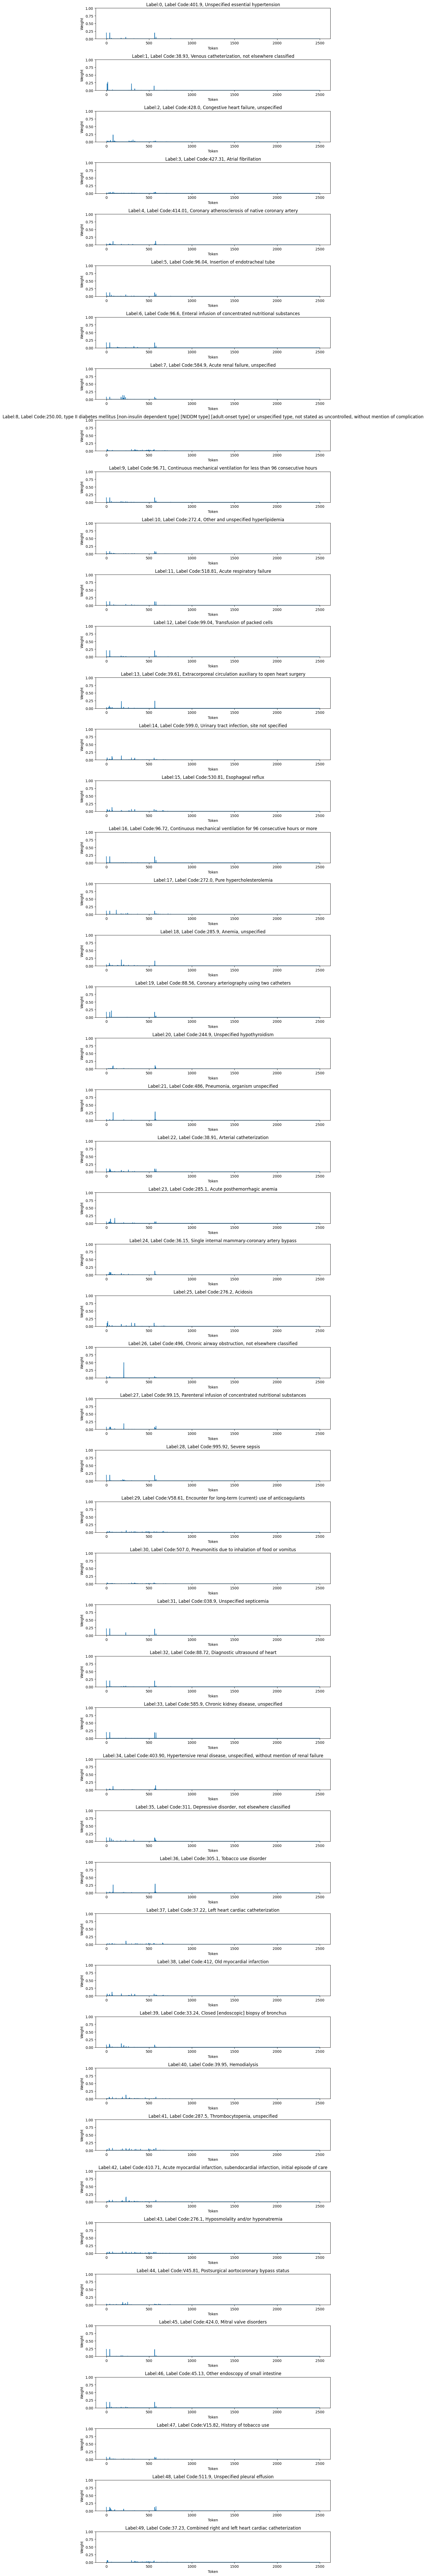

In [ ]:
# This is the attention for the variable instance

num_heads = attn.shape[1]
seq_len = attn.shape[2]

fig, axes = plt.subplots(nrows=num_heads, figsize=(10, 2 * num_heads))

for i in range(num_heads):
    axes[i].plot(attn[0, i].detach().cpu().numpy())
    label_code, label_text = get_ICD_code_by_label_index(i)
    axes[i].set_title("Label:" + str(i) + ", Label Code:" + str(label_code) + ", " + label_text)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel('Weight')
    axes[i].set_xlabel('Token')

plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Load sample
X_sample = X_train[instance].unsqueeze(0)  # shape: [1, seq_len]
Y_sample = Y_train[instance]               # shape: [num_labels]

# Step 2: Run model to get attention
yhat, attn = model(X_sample)

# Step 3: Remove batch dimension and apply sigmoid + threshold
X_sample = X_sample.squeeze(0)             # shape: [seq_len]
yhat = (torch.sigmoid(yhat.squeeze(0)) > 0.5).long()  # shape: [num_labels]

# Step 4: Print header
print(f"{'True':<10} {'Predicted':<12} {'LabelCode':<15} {'LabelText'}")

# Step 5: Print one row for each label index
num_labels = yhat.shape[0]
for i in range(num_labels):
    true_val = int(Y_sample[i])
    pred_val = int(yhat[i])

    # skip rows where both are 0 (neither true nor predicted)
    if true_val == 0 and pred_val == 0:
        continue

    label_code, label_text = get_ICD_code_by_label_index(i)
    # label_text = get_ICD_desc_by_code(label_code)  # assumes this function exists

    print(f"{i:<10} {true_val:<10} {pred_val:<12} {label_code:<15} {label_text}")

True       Predicted    LabelCode       LabelText
4          1          1            414.01          Coronary atherosclerosis of native coronary artery
13         1          1            39.61           Extracorporeal circulation auxiliary to open heart surgery
14         1          0            599.0           Urinary tract infection, site not specified
18         1          1            285.9           Anemia, unspecified
20         1          1            244.9           Unspecified hypothyroidism
21         0          1            486             Pneumonia, organism unspecified
23         1          0            285.1           Acute posthemorrhagic anemia
24         1          1            36.15           Single internal mammary-coronary artery bypass
26         0          1            496             Chronic airway obstruction, not elsewhere classified
34         1          0            403.90          Hypertensive renal disease, unspecified, without mention of renal failure
36  

In [ ]:
# The high attention token sits in the begining of the attention window
def print_true_positive_attention_windows(document_id, top_k=5, window_size=10):
    """
    Prints the top-k attention windows for each true positive label in a given document.
    """
    X_sample = X_train[document_id].unsqueeze(0)
    Y_sample = Y_train[document_id]

    # Run through model
    yhat, attn = model(X_sample)
    yhat = (torch.sigmoid(yhat.squeeze(0)) > 0.5).long()
    attn = attn.squeeze(0)
    X_sample = X_sample.squeeze(0)

    # Trim padding and get tokens
    padding_idx = vocab_size
    document_len = (X_sample != padding_idx).sum().item()
    tokens = [
        word_model.wv.index_to_key[idx.item()] if idx.item() < vocab_size else "[PAD]"
        for idx in X_sample[:document_len]
    ]

    # Get true positives
    correct_indices = [i for i in range(len(yhat)) if yhat[i] == 1 and Y_sample[i] == 1]
    if not correct_indices:
        print(f"\n[Doc {document_id}] No true positive labels.")
        return

    print(f"\n[Doc {document_id}] Showing top-{top_k} attention windows for true positive labels:")

    def extract_windows(attn_seq):
        attn_np = attn_seq.detach().cpu().numpy()
        top_positions = attn_np.argsort()[-(top_k * 3):][::-1]

        starts = sorted(top_positions)
        windows = []
        i = 0
        while i < len(starts):
            start = starts[i]
            end = start + window_size
            if not windows or start >= windows[-1][1]:
                score = attn_np[start:end].sum()
                windows.append((start, end, score))
            i += 1
        windows = sorted(windows, key=lambda x: -x[2])

        seen = set()
        unique = []
        for start, end, score in windows:
            span = " ".join(tokens[start:end])
            if span not in seen:
                seen.add(span)
                unique.append((start, end, score, span, attn_seq[start:end]))
            if len(unique) == top_k:
                break
        return unique

    for label_idx in correct_indices:
        code, desc = get_ICD_code_by_label_index(label_idx)
        attn_seq = attn[label_idx, :document_len]
        windows = extract_windows(attn_seq)

        print(f"\n▶ Label {label_idx}: ICD Code {code} — {desc}")
        for i, (start, end, score, span, attn_vals) in enumerate(windows, 1):
            print(f"\n  Window {i}:")
            print(f"  Token Range: {start} to {end - 1}")
            print(f"  Score: {score:.4f}")
            print(f"  Tokens: {span}")
            print(f"  Attention: {[round(a.item(), 4) for a in attn_vals]}")


In [ ]:
print_true_positive_attention_windows(document_id=instance)


[Doc 1000] Showing top-5 attention windows for true positive labels:

▶ Label 4: ICD Code 414.01 — Coronary atherosclerosis of native coronary artery

  Window 1:
  Token Range: 575 to 584
  Score: 0.2855
  Tokens: disease hypertension hyperlipidemia discharge condition stable discharge instructions go to
  Attention: [0.0241, 0.1195, 0.0702, 0.0363, 0.001, 0.0017, 0.0284, 0.0, 0.0, 0.0043]

  Window 2:
  Token Range: 76 to 85
  Score: 0.2650
  Tokens: gerd htn hyperlipidemia renal calculi social history tobacco yr pack
  Attention: [0.0453, 0.1041, 0.1123, 0.0001, 0.0003, 0.0002, 0.0001, 0.0022, 0.0001, 0.0004]

  Window 3:
  Token Range: 35 to 44
  Score: 0.0952
  Tokens: sp cabg x history of present illness yo m w
  Attention: [0.0345, 0.0003, 0.0021, 0.0, 0.029, 0.029, 0.0, 0.0, 0.0001, 0.0]

  Window 4:
  Token Range: 565 to 574
  Score: 0.0470
  Tokens: discharge diagnosis coronary artery disease chronic renal insufficiency gastroesophageal reflux
  Attention: [0.0287, 0.0063, 0

In [ ]:
# puts the high attention token in the middle of the attention window
def print_true_positive_centered_attention_windows(document_id, top_k=5, window_size=10):
    """
    Prints the top-k attention windows for each true positive label in a given document.
    Windows are centered around the top attention tokens.
    """
    X_sample = X_train[document_id].unsqueeze(0)
    Y_sample = Y_train[document_id]

    # Run model
    yhat, attn = model(X_sample)
    yhat = (torch.sigmoid(yhat.squeeze(0)) > 0.5).long()
    attn = attn.squeeze(0)
    X_sample = X_sample.squeeze(0)

    # Trim padding and get tokens
    padding_idx = vocab_size
    document_len = (X_sample != padding_idx).sum().item()
    tokens = [
        word_model.wv.index_to_key[idx.item()] if idx.item() < vocab_size else "[PAD]"
        for idx in X_sample[:document_len]
    ]

    # Get true positives
    correct_indices = [i for i in range(len(yhat)) if yhat[i] == 1 and Y_sample[i] == 1]
    if not correct_indices:
        print(f"\n[Doc {document_id}] No true positive labels.")
        return

    print(f"\n[Doc {document_id}] Showing top-{top_k} centered attention windows for true positive labels:")

    def extract_centered_windows(attn_seq):
        attn_np = attn_seq.detach().cpu().numpy()
        top_positions = attn_np.argsort()[-(top_k * 3):][::-1]  # more to handle overlaps

        seen = set()
        windows = []
        for center in top_positions:
            half = window_size // 2
            start = max(center - half, 0)
            end = min(start + window_size, len(tokens))
            start = max(end - window_size, 0)  # fix start if at doc end

            span_tokens = tokens[start:end]
            span_text = " ".join(span_tokens)
            if span_text in seen:
                continue
            seen.add(span_text)

            score = attn_np[start:end].sum()
            span_attn = attn_seq[start:end]
            windows.append((start, end, center, score, span_tokens, span_attn))

            if len(windows) == top_k:
                break
        return windows

    # Process and print each correct label
    for label_idx in correct_indices:
        code, desc = get_ICD_code_by_label_index(label_idx)
        attn_seq = attn[label_idx, :document_len]
        windows = extract_centered_windows(attn_seq)

        print(f"\n▶ Label {label_idx}: ICD Code {code} — {desc}")
        for i, (start, end, center, score, span_tokens, span_attn) in enumerate(windows, 1):
            print(f"\n  Window {i}:")
            print(f"  Centered on Token Index: {center}")
            print(f"  Token Range: {start} to {end - 1}")
            print(f"  Score: {score:.4f}")
            print(f"  Tokens: {' '.join(span_tokens)}")
            print(f"  Attention: {[round(a.item(), 4) for a in span_attn]}")


In [ ]:
 print_true_positive_centered_attention_windows(document_id=instance, top_k=5, window_size=10)


[Doc 2413] Showing top-5 centered attention windows for true positive labels:

▶ Label 1: ICD Code 38.93 — Venous catheterization, not elsewhere classified

  Window 1:
  Centered on Token Index: 748
  Token Range: 743 to 752
  Score: 0.4012
  Tokens: medications on admission levothyroxine mcg tablet sig two tablet po
  Attention: [0.0, 0.0275, 0.0004, 0.0, 0.143, 0.2303, 0.0, 0.0, 0.0, 0.0]

  Window 2:
  Centered on Token Index: 794
  Token Range: 789 to 798
  Score: 0.4366
  Tokens: c s refills levothyroxine mcg tablet sig two tablet po
  Attention: [0.0, 0.0, 0.2059, 0.0, 0.0004, 0.2303, 0.0, 0.0, 0.0, 0.0]

  Window 3:
  Centered on Token Index: 791
  Token Range: 786 to 795
  Score: 0.4366
  Tokens: delayed release e c s refills levothyroxine mcg tablet sig
  Attention: [0.0, 0.0, 0.0, 0.0, 0.0, 0.2059, 0.0, 0.0004, 0.2303, 0.0]

  Window 4:
  Centered on Token Index: 747
  Token Range: 742 to 751
  Score: 0.4012
  Tokens: egd medications on admission levothyroxine mcg tablet si